# 1. Data loading

### 1.1 Importing modules

In [35]:
# import all modules
import pandas as pd
import geopandas as gpd
import requests

In [36]:
area_url='https://firms.modaps.eosdis.nasa.gov/api/area/csv/38064bff4711161d2878baf2b432ef5f/VIIRS_NOAA20_NRT/world/2'

response=requests.get(area_url)
# print(response.text) #here I saw that its already plain text and not json to parse, no .json() to unpack required

#Check
if response.status_code==200:
      print("Request worked")
else:
      print("Request did not work")

# Create dataframe
df_area = pd.read_csv(area_url)
df_area

Request worked


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,65.04314,56.66400,325.84,0.48,0.48,2026-05-12,5,N20,VIIRS,n,2.0NRT,268.48,4.12,D
1,65.04477,56.67382,335.23,0.48,0.48,2026-05-12,5,N20,VIIRS,n,2.0NRT,268.20,2.43,D
2,65.04574,56.65567,267.26,0.48,0.48,2026-05-12,5,N20,VIIRS,l,2.0NRT,267.30,0.10,D
3,59.06262,28.13612,295.33,0.47,0.40,2026-05-12,7,N20,VIIRS,n,2.0NRT,271.74,0.83,N
4,59.13012,37.79133,303.11,0.40,0.37,2026-05-12,7,N20,VIIRS,n,2.0NRT,272.41,1.09,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38210,38.46272,65.78693,367.00,0.56,0.69,2026-05-13,937,N20,VIIRS,h,2.0NRT,305.96,7.10,D
38211,38.46505,65.78703,367.00,0.56,0.69,2026-05-13,937,N20,VIIRS,h,2.0NRT,305.74,4.85,D
38212,38.64685,54.28404,349.87,0.44,0.38,2026-05-13,937,N20,VIIRS,n,2.0NRT,322.42,15.29,D
38213,38.93913,64.13549,350.43,0.46,0.63,2026-05-13,937,N20,VIIRS,n,2.0NRT,316.73,17.57,D


# 2. Data cleaning

In [37]:
wildfire_gdf=gpd.GeoDataFrame(df_area, geometry=gpd.points_from_xy(df_area["longitude"], df_area["latitude"]), crs=(4326))
wildfire_gdf.head(3)

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,geometry
0,65.04314,56.66400,325.84,0.48,0.48,2026-05-12,5,N20,VIIRS,n,2.0NRT,268.48,4.12,D,POINT (56.664 65.04314)
1,65.04477,56.67382,335.23,0.48,0.48,2026-05-12,5,N20,VIIRS,n,2.0NRT,268.20,2.43,D,POINT (56.67382 65.04477)
2,65.04574,56.65567,267.26,0.48,0.48,2026-05-12,5,N20,VIIRS,l,2.0NRT,267.30,0.10,D,POINT (56.65567 65.04574)


# 3. Spatial analysis

In [47]:
#Classify wildfire strength
wildfire_gdf["frp"].head(3)
wildfire_gdf["frp"].describe()


count    38215.000000
mean         8.323691
std         15.106730
min          0.020000
25%          2.470000
50%          4.750000
75%          8.660000
max        397.500000
Name: frp, dtype: float64

In [74]:
#Cut off extremes
high_percentile=percentile=wildfire_gdf["frp"].quantile(0.99)
low_percentile=wildfire_gdf["frp"].quantile(0.01)

wildfire_gdf["frp_trimmed"]=wildfire_gdf["frp"].where((wildfire_gdf["frp"]>= low_percentile) & (wildfire_gdf["frp"]<=high_percentile))

In [ ]:
# Set conditions and create categorical column

high_intensity= wildfire_gdf["frp_trimmed"] > 400
medium_intensity= (wildfire_gdf["frp_trimmed"] <= 400) &  (wildfire_gdf["frp_trimmed"] > 200) #instead of and, because pandas different combination
low_intensity=wildfire_gdf["frp_trimmed"] <= 200

wildfire_gdf["intensity_class"]=



In [76]:
# Read in for background map with sha
land = gpd.read_file("../data/raw/ne_10m_land.zip").to_crs(epsg=4326) # eine Ebene höher gehen, um von notebook raus und bei data folder rein
ocean = gpd.read_file("../data/raw/ne_10m_ocean.zip").to_crs(epsg=4326)

In [77]:
!pip install contextily
import contextily as cx

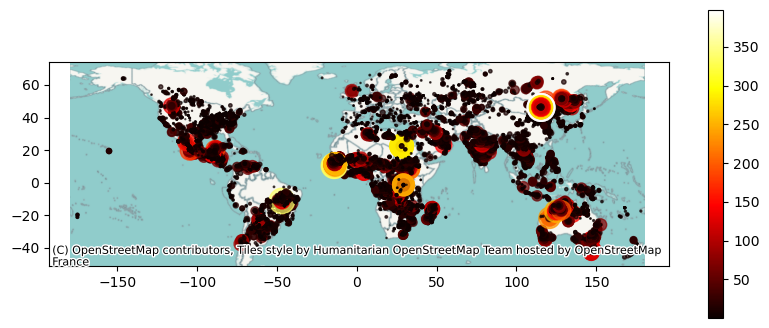

In [81]:
#Without normalization
import contextily as cx

fig, ax= plt.subplots(figsize=(10,4))

wildfire_gdf.plot(ax=ax, column="frp", cmap="hot", markersize="frp", alpha=0.7, legend=True)

cx.add_basemap(
    ax,
    crs="EPSG:4326"
)


<function matplotlib.pyplot.show(close=None, block=None)>

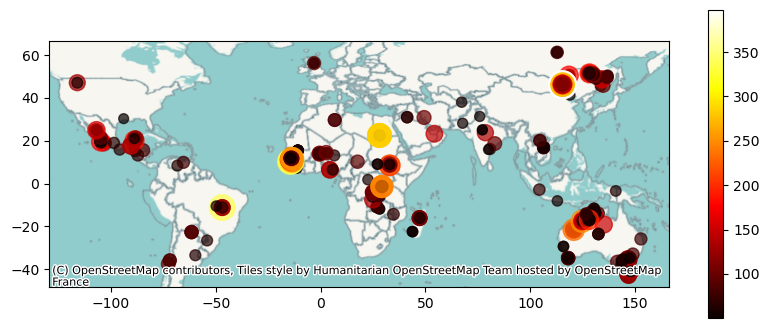

In [110]:
wildfire_gdf["frp_without_min"]=wildfire_gdf["frp"][wildfire_gdf["frp"] > 50]

fig, ax= plt.subplots(figsize=(10,4))

wildfire_gdf.plot(ax=ax, column="frp_without_min", cmap="hot", markersize="frp", alpha=0.7, legend=True)
cx.add_basemap(ax=ax, crs=4326)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

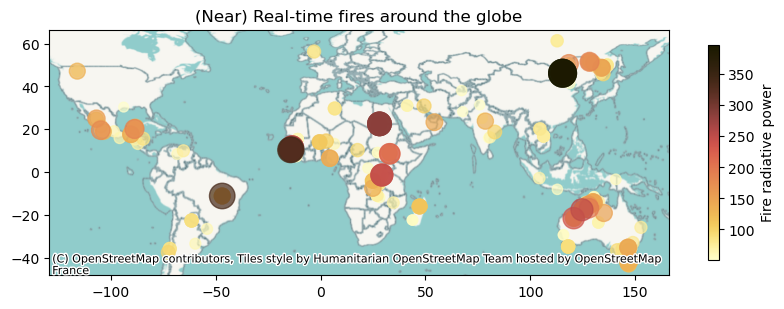

In [135]:
import cmcrameri.cm as cmc
#cmc lipari or OrRd or lajolla

wildfire_gdf["frp_without_min"]=wildfire_gdf["frp"][wildfire_gdf["frp"] > 50]

wildfire_gdf_sorted=wildfire_gdf.sort_values("frp_without_min")

fig, ax= plt.subplots(figsize=(10,4))

legend_options= legend_options = { "label": "Fire radiative power", "orientation": "vertical", "shrink": 0.7}
wildfire_gdf_sorted.plot(ax=ax, column="frp_without_min", cmap="cmc.lajolla_r", markersize="frp", alpha=0.7, legend=True, legend_kwds=legend_options)
cx.add_basemap(ax=ax, crs=4326)
plt.title("(Near) Real-time fires around the globe")
plt.show

In [ ]:
# Make map interactive

import folium

# 1. Initialize the Folium map (The Control)
my_map = folium.Map(zoom_start=12)

# 2. Add multiple datasets using GeoPandas (The Convenience)
wildfire_gdf.explore(m=my_map, color="red", name="Wildfires")

# 3. Add Folium plugins back on top
folium.LayerControl().add_to(my_map)

my_map.save("wildfire_map.html")

In [137]:
import folium

# filter once
wildfire_filtered = wildfire_gdf[wildfire_gdf["frp"] > 50].copy()

# 1. Initialize Folium map
my_map = folium.Map(location=[20, 0], zoom_start=2)

# 2. Add filtered GeoPandas layer
wildfire_filtered.explore(
    m=my_map,
    column="frp",
    cmap="YlOrRd",   # Folium-friendly colormap
    tooltip=["frp"],
    name="Wildfires (FRP > 50)"
)

# 3. Layer control
folium.LayerControl().add_to(my_map)

# 4. Save
my_map.save("wildfire_map2.html")

In [138]:
wildfire_filtered = wildfire_gdf[wildfire_gdf["frp"] > 50].copy()

wildfire_filtered["size"] = wildfire_filtered["frp"] / 10

<Axes: >

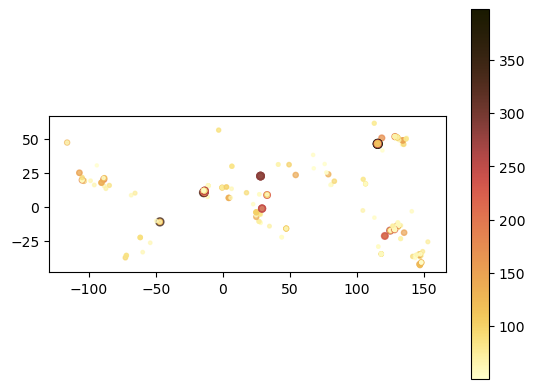

In [139]:
wildfire_filtered.plot(
    column="frp",
    cmap=cmc.lajolla_r,
    markersize="size",
    alpha=0.7,
    legend=True
)

In [143]:
import folium

wildfire_filtered = wildfire_gdf[wildfire_gdf["frp"] > 50].copy()

m = folium.Map(location=[20, 0], zoom_start=2)

for _, row in wildfire_filtered.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=max(np.log1p(row["frp"]) * 2, 2),  # scaling here
        color="red",
        fill=True,
        fill_opacity=0.6,
        popup=f"FRP: {row['frp']:.1f}"
    ).add_to(m)

m.save("wildfire_map3.html")

In [ ]:
# Next step: Do proper map, with normalizing, making classification, handling missing values and so on using this code and practicals VL8
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import cmcrameri.cm as cmc
# import numpy as np

# # 1. Setup
# fig, ax = plt.subplots(figsize=(12, 10))

# # 4. Legend options
# legend_options = {
#     "label": "Ratio: Women per 100 Men",
#     "orientation": "vertical",
#     "shrink": 0.7
# }

# # 6. Missing data options
# missing_styling = {
#     "color": "#EEEEEE",
#     "label": "No Data"
# }

# # 2, 3, 5. Plot the choropleth
# nuts.plot(
#     ax=ax,
#     column="women_per100men",
#     cmap=cmc.vik, 
#     vmin=vmin,
#     vmax=vmax,
#     legend=True,
#     legend_kwds=legend_options,
#     missing_kwds=missing_styling,
#     edgecolor="black",
#     linewidth=0.1
# )

# # 7. Formatting
# ax.set_title("Gender Ratio Across European Regions", fontsize=16)
# ax.axis("off")

# plt.show()

In [ ]:
#Backup, but folium unstable 
# import folium
# from folium.plugins import MarkerCluster

# # Create a new Folium map object.
# background_map = folium.Map()
# folium.GeoJson(wildfire_gdf).add_to(background_map) 
# background_map

# 4. Visualization

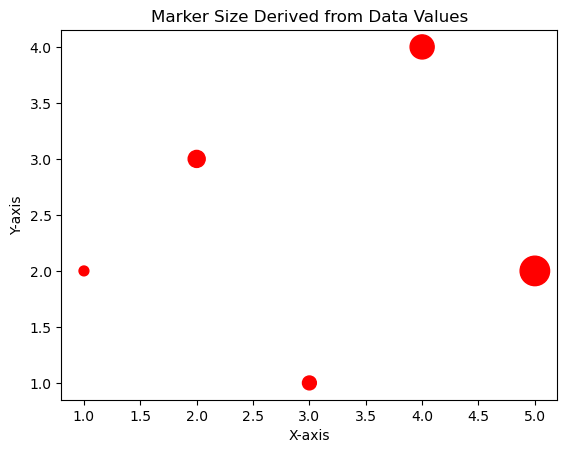

In [ ]:
# Inspirational

# import matplotlib.pyplot as plt
# import numpy as np

# x = np.array([1, 2, 3, 4, 5])
# y = np.array([2, 3, 1, 4, 2])
# data_value = np.array([100, 300, 200, 600, 900])  # data features
# sizes = data_value / 2  # Scale them down

# plt.scatter(x, y, s=sizes, c='red')
# plt.title("Marker Size Derived from Data Values")
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
# plt.show()